# RNN Model for Delinquency Prediction

Uses the **top 50 selected features** from the comprehensive feature selection pipeline.

- Train / Validation / Test split (60/20/20)
- Standardized features
- RNN (GRU-based) with PyTorch
- Handles class imbalance with weighted loss

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: NVIDIA GeForce RTX 4090 Laptop GPU


## 1. Load Data & Selected Features

In [2]:
# Load features
features_df = pd.read_csv('../output/features.csv', index_col=0)

# Load selected feature names
with open('../output/ranked_features.txt', 'r') as f:
    selected_features = [line.strip() for line in f if line.strip()][:75]

print(f'Total consumers: {features_df.shape[0]}')
print(f'Selected features: {len(selected_features)}')
print(f'Delinquency rate: {features_df["DQ_TARGET"].mean():.2%}')

Total consumers: 12900
Selected features: 75
Delinquency rate: 8.86%


## 2. Prepare Data & Train/Val/Test Split

In [3]:
# Clean and subset
df_clean = features_df[features_df['DQ_TARGET'].notna()].copy()
y = df_clean['DQ_TARGET'].astype(int).values

# Keep only selected features
available_features = [f for f in selected_features if f in df_clean.columns]
X = df_clean[available_features].fillna(0).values

print(f'Features used: {len(available_features)}')
print(f'Samples: {X.shape[0]}')
print(f'Class distribution: 0={np.sum(y==0)}, 1={np.sum(y==1)}')

# First split: 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# Second split: 50/50 of temp -> 20% val, 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f'\nTrain: {X_train.shape[0]} ({y_train.mean():.2%} positive)')
print(f'Val:   {X_val.shape[0]} ({y_val.mean():.2%} positive)')
print(f'Test:  {X_test.shape[0]} ({y_test.mean():.2%} positive)')

Features used: 75
Samples: 10317
Class distribution: 0=9403, 1=914

Train: 6190 (8.85% positive)
Val:   2063 (8.87% positive)
Test:  2064 (8.87% positive)


In [4]:
# Standardize features (fit on train only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Reshape for RNN: (batch, seq_len, input_size)
# Treat each feature as a time step with 1 input dimension
n_features = X_train_scaled.shape[1]
X_train_rnn = X_train_scaled.reshape(-1, n_features, 1)
X_val_rnn = X_val_scaled.reshape(-1, n_features, 1)
X_test_rnn = X_test_scaled.reshape(-1, n_features, 1)

print(f'RNN input shape: {X_train_rnn.shape}  (batch, seq_len={n_features}, input_size=1)')

# Create DataLoaders
def make_loader(X, y, batch_size=256, shuffle=True):
    ds = TensorDataset(
        torch.FloatTensor(X),
        torch.FloatTensor(y)
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train_rnn, y_train, shuffle=True)
val_loader = make_loader(X_val_rnn, y_val, shuffle=False)
test_loader = make_loader(X_test_rnn, y_test, shuffle=False)

print(f'Batches -> Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}')

RNN input shape: (6190, 75, 1)  (batch, seq_len=75, input_size=1)
Batches -> Train: 25, Val: 9, Test: 9


## 3. Define RNN Model

In [5]:
class DelinquencyRNN(nn.Module):
    """GRU-based RNN for binary classification."""
    
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )
        self.attention = nn.Sequential(
            nn.Linear(hidden_size * 2, 1),
            nn.Tanh()
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        # x: (batch, seq_len, input_size)
        gru_out, _ = self.gru(x)  # (batch, seq_len, hidden*2)
        
        # Attention pooling
        attn_weights = self.attention(gru_out)  # (batch, seq_len, 1)
        attn_weights = torch.softmax(attn_weights, dim=1)
        context = torch.sum(attn_weights * gru_out, dim=1)  # (batch, hidden*2)
        
        out = self.classifier(context)  # (batch, 1)
        return out.squeeze(-1)

model = DelinquencyRNN(input_size=1, hidden_size=64, num_layers=2, dropout=0.3).to(device)
print(model)
print(f'\nParameters: {sum(p.numel() for p in model.parameters()):,}')

DelinquencyRNN(
  (gru): GRU(1, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Sequential(
    (0): Linear(in_features=128, out_features=1, bias=True)
    (1): Tanh()
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

Parameters: 104,514


## 4. Training

In [6]:
# Class weight for imbalanced data
pos_weight = torch.tensor([(y_train == 0).sum() / max((y_train == 1).sum(), 1)]).to(device)
print(f'Positive class weight: {pos_weight.item():.2f}')

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=True
)

# Training loop
NUM_EPOCHS = 50
PATIENCE = 10

history = {'train_loss': [], 'val_loss': [], 'val_auc': []}
best_val_auc = 0
patience_counter = 0
best_state = None

# Start timing
training_start_time = time.time()

for epoch in range(NUM_EPOCHS):
    # --- Train ---
    model.train()
    train_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_losses.append(loss.item())
    
    avg_train_loss = np.mean(train_losses)
    
    # --- Validate ---
    model.eval()
    val_losses, val_preds, val_targets = [], [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            val_losses.append(criterion(logits, y_batch).item())
            val_preds.extend(torch.sigmoid(logits).cpu().tolist())
            val_targets.extend(y_batch.cpu().tolist())
    
    avg_val_loss = np.mean(val_losses)
    val_auc = roc_auc_score(val_targets, val_preds)
    
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_auc'].append(val_auc)
    
    scheduler.step(avg_val_loss)
    
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        patience_counter = 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
    
    if (epoch + 1) % 5 == 0 or patience_counter == 0:
        print(f'Epoch {epoch+1:3d} | Train Loss: {avg_train_loss:.4f} | '
              f'Val Loss: {avg_val_loss:.4f} | Val AUC: {val_auc:.4f} '
              f'{"*" if patience_counter == 0 else ""}')
    
    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch+1}. Best Val AUC: {best_val_auc:.4f}')
        break

# End timing
training_end_time = time.time()
training_time = training_end_time - training_start_time

# Restore best model
if best_state:
    model.load_state_dict(best_state)
    model.to(device)
print(f'\nBest Validation AUC: {best_val_auc:.4f}')
print(f'Total Training Time: {training_time:.2f} seconds ({training_time/60:.2f} minutes)')


Positive class weight: 10.30
Epoch   1 | Train Loss: 1.2660 | Val Loss: 1.2023 | Val AUC: 0.5256 *
Epoch   2 | Train Loss: 1.2624 | Val Loss: 1.2069 | Val AUC: 0.5273 *
Epoch   3 | Train Loss: 1.2533 | Val Loss: 1.2024 | Val AUC: 0.5313 *
Epoch   4 | Train Loss: 1.2565 | Val Loss: 1.1983 | Val AUC: 0.5390 *
Epoch   5 | Train Loss: 1.2486 | Val Loss: 1.1965 | Val AUC: 0.5485 *
Epoch   6 | Train Loss: 1.2408 | Val Loss: 1.1952 | Val AUC: 0.5518 *
Epoch   7 | Train Loss: 1.2464 | Val Loss: 1.1981 | Val AUC: 0.5917 *
Epoch  10 | Train Loss: 1.2524 | Val Loss: 1.1917 | Val AUC: 0.5715 
Epoch  11 | Train Loss: 1.2381 | Val Loss: 1.1919 | Val AUC: 0.5991 *
Epoch  12 | Train Loss: 1.2417 | Val Loss: 1.1896 | Val AUC: 0.6158 *
Epoch  15 | Train Loss: 1.2423 | Val Loss: 1.1818 | Val AUC: 0.6146 
Epoch  17 | Train Loss: 1.2225 | Val Loss: 1.1689 | Val AUC: 0.6179 *
Epoch  19 | Train Loss: 1.2227 | Val Loss: 1.1581 | Val AUC: 0.6215 *
Epoch  20 | Train Loss: 1.2213 | Val Loss: 1.1475 | Val AUC: 0.

## 5. Training Curves

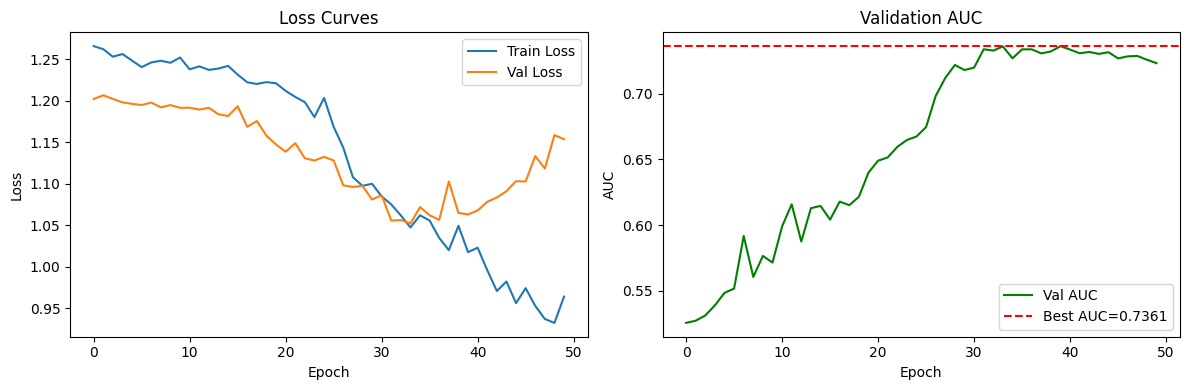

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves')
axes[0].legend()

axes[1].plot(history['val_auc'], label='Val AUC', color='green')
axes[1].axhline(y=best_val_auc, color='r', linestyle='--', label=f'Best AUC={best_val_auc:.4f}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].set_title('Validation AUC')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Evaluation on All Splits

In [8]:
def evaluate(model, loader, split_name):
    """Evaluate model and print metrics."""
    scoring_start = time.time()
    
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            probs = torch.sigmoid(logits).cpu().tolist()
            all_preds.extend(probs)
            all_targets.extend(y_batch.tolist())
    
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    
    # AUC
    auc = roc_auc_score(all_targets, all_preds)
    ap = average_precision_score(all_targets, all_preds)
    
    # Binary predictions at 0.5 threshold
    y_pred = (all_preds >= 0.5).astype(int)
    
    scoring_time = time.time() - scoring_start
    
    print(f'\n{"="*50}')
    print(f'{split_name} Results')
    print(f'{"="*50}')
    print(f'ROC-AUC: {auc:.4f}')
    print(f'Average Precision: {ap:.4f}')
    print(f'Scoring Time: {scoring_time:.4f} seconds')
    print(f'\nClassification Report:')
    print(classification_report(all_targets, y_pred, target_names=['No DQ', 'DQ']))
    print(f'Confusion Matrix:')
    print(confusion_matrix(all_targets, y_pred))
    
    return all_preds, all_targets, auc, scoring_time

train_preds, train_targets, train_auc, train_time = evaluate(model, train_loader, 'TRAIN')
val_preds, val_targets, val_auc, val_time = evaluate(model, val_loader, 'VALIDATION')
test_preds, test_targets, test_auc, test_time = evaluate(model, test_loader, 'TEST')



TRAIN Results
ROC-AUC: 0.8023
Average Precision: 0.2695
Scoring Time: 0.0790 seconds

Classification Report:
              precision    recall  f1-score   support

       No DQ       0.97      0.73      0.83      5642
          DQ       0.21      0.73      0.33       548

    accuracy                           0.73      6190
   macro avg       0.59      0.73      0.58      6190
weighted avg       0.90      0.73      0.79      6190

Confusion Matrix:
[[4146 1496]
 [ 149  399]]

VALIDATION Results
ROC-AUC: 0.7361
Average Precision: 0.1994
Scoring Time: 0.0146 seconds

Classification Report:
              precision    recall  f1-score   support

       No DQ       0.95      0.72      0.82      1880
          DQ       0.18      0.61      0.27       183

    accuracy                           0.71      2063
   macro avg       0.56      0.66      0.55      2063
weighted avg       0.88      0.71      0.77      2063

Confusion Matrix:
[[1358  522]
 [  72  111]]

TEST Results
ROC-AUC: 0.7212
A

## 7. Precision-Recall Curves

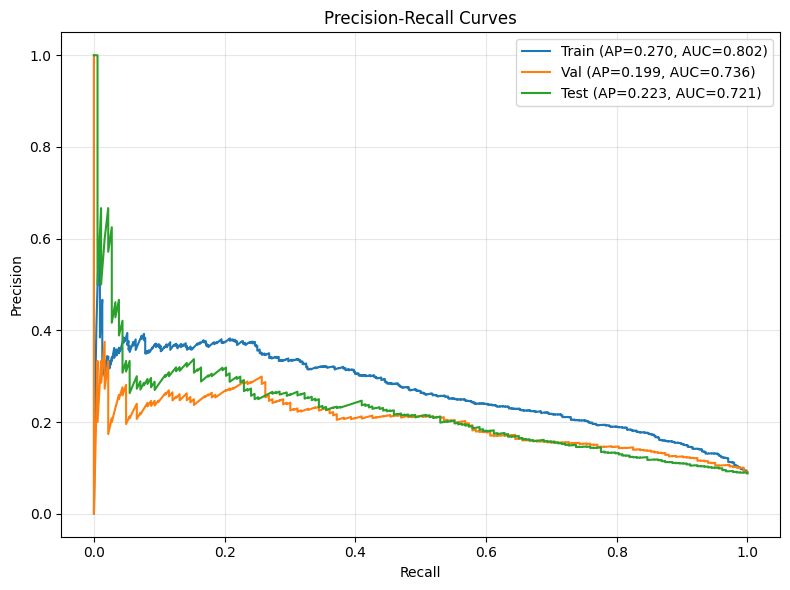

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

for preds, targets, name, auc_val in [
    (train_preds, train_targets, 'Train', train_auc),
    (val_preds, val_targets, 'Val', val_auc),
    (test_preds, test_targets, 'Test', test_auc)
]:
    precision, recall, _ = precision_recall_curve(targets, preds)
    ap = average_precision_score(targets, preds)
    ax.plot(recall, precision, label=f'{name} (AP={ap:.3f}, AUC={auc_val:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Summary

In [10]:
print('RNN Model Summary')
print('=' * 40)
print(f'Architecture: Bidirectional GRU')
print(f'Hidden size: 64, Layers: 2')
print(f'Features used: {len(available_features)}')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'')
print(f'Training Time: {training_time:.2f}s ({training_time/60:.2f} min)')
print(f'')
print(f'          AUC      Scoring Time')
print(f'Train:    {train_auc:.4f}   {train_time:.4f}s')
print(f'Val:      {val_auc:.4f}   {val_time:.4f}s')
print(f'Test:     {test_auc:.4f}   {test_time:.4f}s')


RNN Model Summary
Architecture: Bidirectional GRU
Hidden size: 64, Layers: 2
Features used: 75
Parameters: 104,514

Training Time: 7.81s (0.13 min)

          AUC      Scoring Time
Train:    0.8023   0.0790s
Val:      0.7361   0.0146s
Test:     0.7212   0.0146s
